# Certified Robustness via Randomized Smoothing

Every other defense in this repo (`01_preprocessing_defenses.ipynb`, `02_detection.ipynb`, and adversarial training) is evaluated **empirically**: we throw a fixed list of attacks at it and report how many it stops. That is inherently incomplete: it says nothing about an attack we did not think to try.

**Randomized Smoothing** (Cohen, Rosenfeld & Kolter, 2019) is different: it produces a **provable, certified $L_2$ radius** around each input, inside which *no* attack, regardless of algorithm, white-box or black-box, known or not yet invented, can change the prediction. It works by wrapping any pre-trained base classifier $f$ (no retraining required) into a smoothed classifier:
$$g(x) = \arg\max_{c} \; \mathbb{P}_{\delta \sim \mathcal{N}(0, \sigma^2 I)}\big[f(x + \delta) = c\big]$$

If the most likely class under this noise distribution has probability $p_A$, Cohen et al. prove that $g$ is provably correct within an $L_2$ ball of radius:
$$R = \sigma \cdot \Phi^{-1}(\underline{p_A})$$
where $\Phi^{-1}$ is the inverse standard Gaussian CDF and $\underline{p_A}$ is a lower confidence bound on $p_A$, estimated via Monte Carlo sampling.


In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from scipy.stats import norm, binomtest

from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob

### Setup
Noise is added in the model's own preprocessed input space, so `noise_scale` converts $\sigma$ (specified in normalized `[0, 1]` units, for comparability across models) into the actual scale of each model's input range, the same role `eps_scale` plays in the attack notebooks.

In [2]:
models_dict = {
    'MobileNetV2': {'model': MobileNetV2(weights='imagenet'), 'target_size': (224, 224), 'preprocess_fn': preprocess_mob,
                     'clip_min': -1.0, 'clip_max': 1.0, 'noise_scale': 2.0},
    'EfficientNetB0': {'model': EfficientNetB0(weights='imagenet'), 'target_size': (224, 224), 'preprocess_fn': preprocess_eff,
                        'clip_min': 0.0, 'clip_max': 255.0, 'noise_scale': 255.0},
    # InceptionV3 is too heavy
    # 'InceptionV3': {'model': InceptionV3(weights='imagenet'), 'target_size': (299, 299), 'preprocess_fn': preprocess_inc,
    #                  'clip_min': -1.0, 'clip_max': 1.0, 'noise_scale': 2.0},
}

for config in models_dict.values():
    config['model'].trainable = False

def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img)
    return tf.expand_dims(img, axis=0)

### The `certify` Procedure
We follow Cohen et al.'s `CERTIFY` algorithm directly: draw `n` noisy copies of $x$, batch them through the model, take the majority-vote class $\hat{c}_A$, then compute a one-sided Clopper-Pearson lower confidence bound $\underline{p_A}$ on its true probability at confidence level $1 - \alpha$. If $\underline{p_A} \le 0.5$ the procedure **abstains**: there isn't enough statistical evidence to certify anything, which is the correct, honest behavior rather than reporting a radius of 0.

In [3]:
ABSTAIN = -1

def sample_noisy_predictions(model, x, sigma_scaled, n, clip_min, clip_max, batch_size=100):
    """Draws `n` noisy copies of `x`, batched through the model, and returns their predicted class indices."""
    all_preds = []
    remaining = n
    while remaining > 0:
        b = min(batch_size, remaining)
        noise = tf.random.normal(shape=(b,) + x.shape[1:], stddev=sigma_scaled)
        noisy_batch = tf.clip_by_value(x + noise, clip_min, clip_max)
        preds = model(noisy_batch, training=False)
        all_preds.append(tf.argmax(preds, axis=-1).numpy())
        remaining -= b
    return np.concatenate(all_preds)

def certify(model, x, sigma, clip_min, clip_max, noise_scale, n0=100, n=500, alpha=0.001, batch_size=100):
    """Randomized smoothing certification (Cohen et al., 2019). Returns (predicted_class, certified_L2_radius),
    or (ABSTAIN, 0.0) if there isn't enough statistical confidence."""
    sigma_scaled = sigma * noise_scale

    # Step 1: use a small sample (n0) just to select the most likely class
    selection_preds = sample_noisy_predictions(model, x, sigma_scaled, n0, clip_min, clip_max, batch_size)
    c_a_hat = np.bincount(selection_preds).argmax()

    # Step 2: use a larger, independent sample (n) to estimate p_A with a statistical guarantee
    estimation_preds = sample_noisy_predictions(model, x, sigma_scaled, n, clip_min, clip_max, batch_size)
    count_a = int(np.sum(estimation_preds == c_a_hat))

    # One-sided Clopper-Pearson lower confidence bound on p_A at level 1 - alpha
    p_a_lower = binomtest(count_a, n, p=0.5).proportion_ci(confidence_level=1 - 2 * alpha, method='exact').low

    if p_a_lower <= 0.5:
        return ABSTAIN, 0.0

    radius = sigma * norm.ppf(p_a_lower)
    return int(c_a_hat), float(radius)

### Certified Accuracy vs. Radius
For each model and noise level $\sigma$, we certify every image in a subset of `images/miniimagenet_random_100/` and plot **certified accuracy at radius $r$**: the fraction of images that are both (a) correctly classified and (b) certified with a radius $\ge r$. This is the standard way to report randomized smoothing results: a curve, not a single number, since larger $\sigma$ trades clean accuracy for a larger guaranteed radius.

In [4]:
NUM_IMAGES = 20
SIGMAS = [0.12, 0.25, 0.50]

image_paths = sorted(glob.glob('../images/miniimagenet_random_100/*.*'))[:NUM_IMAGES]

certify_rows = []

for model_name, m_config in models_dict.items():
    print(f"\n{'='*80}\nCERTIFYING MODEL: {model_name}\n{'='*80}")
    current_model = m_config['model']

    for i, img_path in enumerate(image_paths):
        input_img = load_and_preprocess_image(img_path, m_config['target_size'], m_config['preprocess_fn'])
        true_idx = int(tf.argmax(current_model.predict(input_img, verbose=0), axis=-1)[0])  # clean prediction as ground truth

        for sigma in SIGMAS:
            pred_idx, radius = certify(current_model, input_img, sigma, m_config['clip_min'], m_config['clip_max'], m_config['noise_scale'])
            certify_rows.append({
                'Model': model_name,
                'Image': img_path,
                'Sigma': sigma,
                'True_Idx': true_idx,
                'Certified_Idx': pred_idx,
                'Correct': bool(pred_idx == true_idx),
                'Radius': radius if pred_idx != ABSTAIN else 0.0,
            })

            print(f"  Image {i+1}/{len(image_paths)} | sigma={sigma}", flush=True)

certify_df = pd.DataFrame(certify_rows)
certify_df.to_csv('certified_radii.csv', index=False)
print(f"\nSaved {len(certify_df)} rows -> certified_radii.csv")


CERTIFYING MODEL: MobileNetV2
  Image 1/20 | sigma=0.12
  Image 1/20 | sigma=0.25
  Image 1/20 | sigma=0.5
  Image 2/20 | sigma=0.12
  Image 2/20 | sigma=0.25
  Image 2/20 | sigma=0.5
  Image 3/20 | sigma=0.12
  Image 3/20 | sigma=0.25
  Image 3/20 | sigma=0.5
  Image 4/20 | sigma=0.12
  Image 4/20 | sigma=0.25
  Image 4/20 | sigma=0.5
  Image 5/20 | sigma=0.12
  Image 5/20 | sigma=0.25
  Image 5/20 | sigma=0.5
  Image 6/20 | sigma=0.12
  Image 6/20 | sigma=0.25
  Image 6/20 | sigma=0.5
  Image 7/20 | sigma=0.12
  Image 7/20 | sigma=0.25
  Image 7/20 | sigma=0.5
  Image 8/20 | sigma=0.12
  Image 8/20 | sigma=0.25
  Image 8/20 | sigma=0.5
  Image 9/20 | sigma=0.12
  Image 9/20 | sigma=0.25
  Image 9/20 | sigma=0.5
  Image 10/20 | sigma=0.12
  Image 10/20 | sigma=0.25
  Image 10/20 | sigma=0.5
  Image 11/20 | sigma=0.12
  Image 11/20 | sigma=0.25
  Image 11/20 | sigma=0.5
  Image 12/20 | sigma=0.12
  Image 12/20 | sigma=0.25
  Image 12/20 | sigma=0.5
  Image 13/20 | sigma=0.12
  Image 1

c:\Users\frang\Desktop\adv_at\adversarial_attacks_vision\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\frang\Desktop\adv_at\adversarial_attacks_vision\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


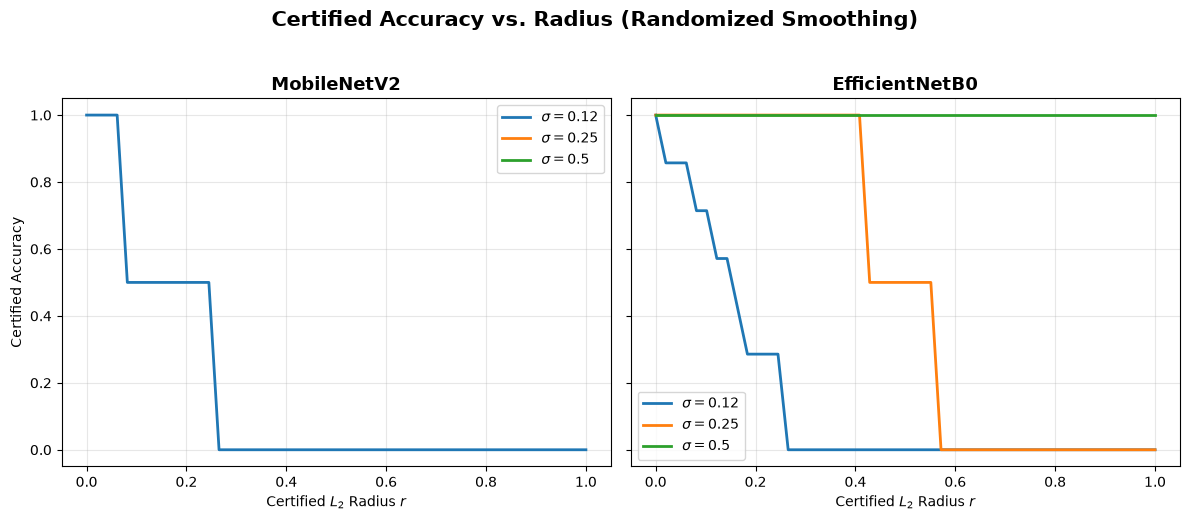

In [5]:
def certified_accuracy_curve(df, radii):
    """Fraction of images that are correct AND certified with a radius >= r, for each r."""
    correct_radii = df.loc[df['Correct'], 'Radius'].values
    n_total = len(df)
    return [np.mean(correct_radii >= r) if n_total > 0 else 0.0 for r in radii]
    # Note: normalizes by all images (not just correct ones), matching the standard definition

radii_grid = np.linspace(0, 1.0, 50)

fig, axes = plt.subplots(1, len(models_dict), figsize=(6 * len(models_dict), 5), sharey=True)

for ax, model_name in zip(axes, models_dict.keys()):
    model_df = certify_df[certify_df['Model'] == model_name]
    for sigma in SIGMAS:
        sigma_df = model_df[model_df['Sigma'] == sigma]
        acc_curve = certified_accuracy_curve(sigma_df, radii_grid)
        ax.plot(radii_grid, acc_curve, label=f'$\\sigma={sigma}$', linewidth=2)

    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Certified $L_2$ Radius $r$')
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Certified Accuracy')
plt.suptitle('Certified Accuracy vs. Radius (Randomized Smoothing)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()